6/25/26

# v9 — Dropout

This builds directly on **v8**. Steps 1–7 below carry over as-is (setup), and `TransformerBlock` / `BigramLanguageModel` / training are also unchanged in structure.

What's new: a single hyperparameter, `dropout`, applied in three places — after the attention softmax (`Head`), after the output projection (`MultiHeadAttention`), and after the feed-forward MLP (`FeedForward`) — to regularize the model now that it's deep and wide enough to start overfitting.

*dropout is one of the ways we prevent models from overfitting*

*prevents a few attention heads from trying to overpower all of the others; want all of the heads to learn something at each point?*

*we want to prevent dead neurons (where a few neurons end up learning nothing), so we intentionally remove a few at each step temporarilly*

## 1. Imports

In [1]:
import os
import torch
import torch.nn as nn
from torch.nn import functional as F

## 2. Hyperparameters

`block_size` doubles to 256 (more context), and `dropout` is new.

In [2]:
# out_dir = 'output'
# emb_size = 128
# batch_size = 64
# block_size = 256      # was 128 in v8
# max_iters = 10000
# eval_interval = 500
# learning_rate = 3e-4
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# eval_iters = 200
# num_layers = 4
# num_heads = 8
# seed = 42
# best_val_loss = float('inf')
# dropout = 0.05        # NEW: dropout rate

# torch.manual_seed(seed)

In [3]:
# Sabine's version of the above block that does hardware detection (that way on Mac it uses GPU if available rather than CPU default)
# Detect best available device (CUDA>MPS>CPU) and set DataLoader workers accordingly
import os

out_dir = 'output'
emb_size = 128
batch_size = 64
block_size = 256      # was 128 in v8
max_iters = 10000
eval_interval = 500
learning_rate = 3e-4
eval_iters = 200
num_layers = 4
num_heads = 8
seed = 42
best_val_loss = float('inf')
dropout = 0.05        # NEW: dropout rate


if torch.cuda.is_available():
    device = torch.device("cuda")
    total_cores = os.cpu_count()
    NUM_WORKERS = min(8, max(1, total_cores - 2))

elif torch.backends.mps.is_available():
    device = torch.device("mps")
    NUM_WORKERS = 0  # MPS + multiprocessing can hang

else:
    device = torch.device("cpu")
    NUM_WORKERS = 0

print(f"Using device: {device}")
torch.manual_seed(seed)

Using device: cuda


## 3. Load the dataset

In [4]:
with open('./data/harry_potter.txt', encoding='utf-8') as f:
    text = f.read()

print(f"length of dataset in characters: {len(text)}")
print(text[:500])

length of dataset in characters: 5991293
THE BOY WHO LIVED Mr and Mrs Dursley of number four Privet Drive were proud to say that they were perfectly normal thank you very much .They were the last people youd expect to be involved in anything strange or mysterious because they just didnt hold with such nonsense .Mr Dursley was the director of a firm called Grunnings which made drills .He was a big beefy man with hardly any neck although he did have a very large mustache .Mrs Dursley was thin and blonde and had nearly twice the usual amo


## 4. Tokenization: characters as tokens

In [5]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)

 !.0123456789?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz~‘•■□
71


In [6]:
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("Hello there!"))
print(decode(encode("Hello there!")))

[21, 44, 51, 51, 54, 0, 59, 47, 44, 57, 44, 1]
Hello there!


## 5. Train / validation split

In [7]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

print(data.shape, data.dtype)
print(data[:100])

torch.Size([5991293]) torch.int64
tensor([33, 21, 18,  0, 15, 28, 38,  0, 36, 21, 28,  0, 25, 22, 35, 18, 17,  0,
        26, 57,  0, 40, 53, 43,  0, 26, 57, 58,  0, 17, 60, 57, 58, 51, 44, 64,
         0, 54, 45,  0, 53, 60, 52, 41, 44, 57,  0, 45, 54, 60, 57,  0, 29, 57,
        48, 61, 44, 59,  0, 17, 57, 48, 61, 44,  0, 62, 44, 57, 44,  0, 55, 57,
        54, 60, 43,  0, 59, 54,  0, 58, 40, 64,  0, 59, 47, 40, 59,  0, 59, 47,
        44, 64,  0, 62, 44, 57, 44,  0, 55, 44])


## 6. Batching

In [8]:
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

In [9]:
xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

inputs:
torch.Size([64, 256])
tensor([[ 0, 59, 47,  ..., 48, 54, 53],
        [51,  0, 41,  ..., 57, 57, 64],
        [ 0, 40, 53,  ..., 29, 44, 57],
        ...,
        [57, 64,  0,  ..., 53, 44,  0],
        [65, 50, 40,  ..., 44,  0,  2],
        [54, 57, 64,  ..., 40, 48, 58]], device='cuda:0')
targets:
torch.Size([64, 256])
tensor([[59, 47, 44,  ..., 54, 53,  0],
        [ 0, 41, 44,  ..., 57, 64,  0],
        [40, 53,  0,  ..., 44, 57, 42],
        ...,
        [64,  0, 22,  ..., 44,  0, 48],
        [50, 40, 41,  ...,  0,  2, 36],
        [57, 64,  0,  ..., 48, 58, 44]], device='cuda:0')


## 7. Estimating loss

In [10]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

## 8. Self-attention head — what's new

Dropout is applied to the attention weights themselves, right after the softmax — randomly zeroing out some of the attention connections during training so the model can't over-rely on any single one.

**In class:** fill in the parts marked **NEW** below.

In [11]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(emb_size, head_size, bias=False)
        self.query = nn.Linear(emb_size, head_size, bias=False)
        self.value = nn.Linear(emb_size, head_size, bias=False)
        # NEW: dropout applied to the attention weights
        self.att_dropout = nn.Dropout(dropout)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        key = self.key(x) # (B,T,H)
        query = self.query(x) # (B,T,H)

        # compute the attention weights
        dot_products = query @ key.transpose(-2,-1) * C**-0.5 # (B,T,H) @ (B,H,T) = (B,T,T) # scale by sqrt(d_k)
        dot_products = dot_products.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # mask out the upper triangular part
        weights = F.softmax(dot_products, dim=-1) # (B,T,T) Apply softmax to get the attention weights
        # NEW: randomly zero out some attention weights during training
        weights = self.att_dropout(weights)

        # apply the attention weights to the values
        value = self.value(x) # (B,T,H)
        out = weights @ value # (B,T,T) @ (B,T,H) = (B,T,H)
        return out

## 9. Multi-head attention — what's new

Dropout is also applied after the output projection, before the result rejoins the residual stream.

**In class:** fill in the parts marked **NEW** below.

In [12]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(emb_size, emb_size)
        # NEW: dropout applied after the output projection
        self.res_dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = torch.cat([head(x) for head in self.heads], dim=-1)
        # NEW: project, then dropout
        x = self.res_dropout(self.proj(x))
        return x

## 10. Feed-forward layer — what's new

Same idea: dropout right before the feed-forward output rejoins the residual stream.

**In class:** fill in the parts marked **NEW** below.

In [13]:
class FeedForward(nn.Module):
    def __init__(self, emb_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_size, 4 * emb_size),
            nn.ReLU(),
            nn.Linear(4 * emb_size, emb_size),
        )
        # NEW: dropout applied to the feed-forward output
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # NEW: net, then dropout
        return self.dropout(self.net(x))

## 11. Transformer block (recap)

In [14]:
class TransformerBlock(nn.Module):
    def __init__(self, embd_size, num_heads):
        super().__init__()
        head_size = embd_size // num_heads
        self.att_head = MultiHeadAttention(num_heads, head_size)
        self.feedforward = FeedForward(emb_size)
        self.ln1 = nn.LayerNorm(emb_size)
        self.ln2 = nn.LayerNorm(emb_size)

    def forward(self, x):
        x = x + self.att_head(self.ln1(x))
        x = x + self.feedforward(self.ln2(x))
        return x

## 12. The model (recap)

In [15]:
class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size, emb_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, emb_size)
        # we will get to the position embeddings later
        self.position_embedding_table = nn.Embedding(block_size, emb_size)
        self.blocks = nn.Sequential(*[TransformerBlock(emb_size, num_heads=num_heads) for _ in range(num_layers)])
        self.linear_head = nn.Linear(emb_size, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        logits = self.linear_head(x)  # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the block size
            idx_cond = idx[:, -block_size:] # (B, T)

            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

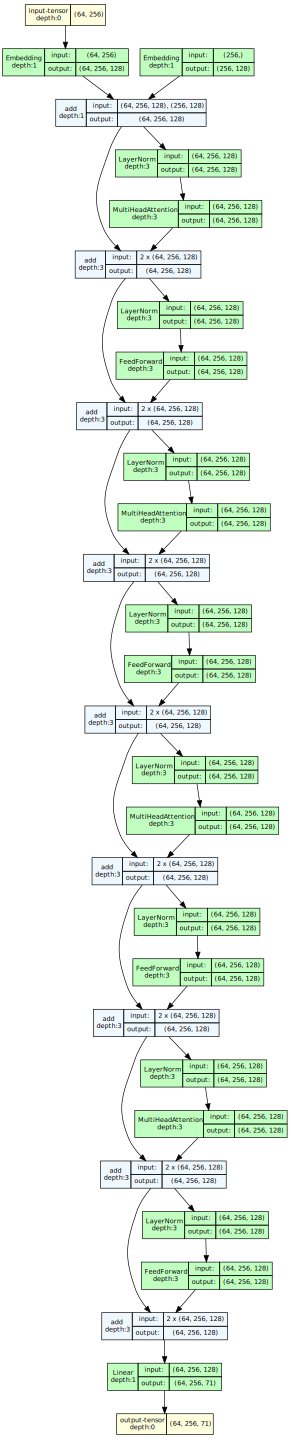

In [16]:
from torchview import draw_graph

model_graph = draw_graph(
    BigramLanguageModel(vocab_size, emb_size),
    input_size=(batch_size, block_size),
    dtypes=[torch.long]
)
model_graph.visual_graph

In [17]:
BigramLanguageModel(vocab_size, emb_size)

BigramLanguageModel(
  (token_embedding_table): Embedding(71, 128)
  (position_embedding_table): Embedding(256, 128)
  (blocks): Sequential(
    (0): TransformerBlock(
      (att_head): MultiHeadAttention(
        (heads): ModuleList(
          (0-7): 8 x Head(
            (key): Linear(in_features=128, out_features=16, bias=False)
            (query): Linear(in_features=128, out_features=16, bias=False)
            (value): Linear(in_features=128, out_features=16, bias=False)
            (att_dropout): Dropout(p=0.05, inplace=False)
          )
        )
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (res_dropout): Dropout(p=0.05, inplace=False)
      )
      (feedforward): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=128, bias=True)
        )
        (dropout): Dropout(p=0.05, inplace=False)
      )
      (ln1): LayerNo

## 13. Sanity check: untrained generation

Note `estimate_loss` and `generate` both call the model without setting it to `.eval()` aware of dropout manually — `model.eval()` / `model.train()` (already in `estimate_loss`) is what turns dropout off and on, so we get deterministic evaluation and stochastic training for free.

In [18]:
model = BigramLanguageModel(vocab_size, emb_size)
model = model.to(device)

model_args = dict(n_layer=num_layers, n_head=num_heads, n_embd=emb_size, block_size=block_size,
                   bias=False, vocab_size=None)

# print the number of parameters in the model
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=200)[0].tolist()))

0.842567 M parameters
 W01svEuo7ItD27dCb4H9P2gkgXQ2yvZa nNiE3D!VCKM.s8ZN‘LLut JogC 7RV•priKtiazRd4B□ny4XTF8ym7QCvcl2g2th7!0B□ LUhM.RuTn!hA•9FlkS‘BlC•tx•Jhf1•NqTm‘~HrExK■EQ5?QWiKbo4R5‘□FJiicrZch6!dQ4Rf4mrJYgLT7i6yX15N9CAqjkO


## 14. Training the model

In [19]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

        if losses['val'] < best_val_loss and iter % eval_interval == 0:
            best_val_loss = losses['val']
            checkpoint = {
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'model_args': model_args,
                'iter_num': iter,
                'best_val_loss': best_val_loss,
            }
            print(f"saving checkpoint to {out_dir}")
            torch.save(checkpoint, os.path.join(out_dir, 'v9_ckpt.pt'))

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step 0: train loss 4.5685, val loss 4.5677
saving checkpoint to output
step 500: train loss 2.3724, val loss 2.3559
saving checkpoint to output
step 1000: train loss 2.1927, val loss 2.1763
saving checkpoint to output
step 1500: train loss 1.9458, val loss 1.9407
saving checkpoint to output
step 2000: train loss 1.8010, val loss 1.8040
saving checkpoint to output
step 2500: train loss 1.7045, val loss 1.7145
saving checkpoint to output
step 3000: train loss 1.6315, val loss 1.6446
saving checkpoint to output
step 3500: train loss 1.5729, val loss 1.5880
saving checkpoint to output
step 4000: train loss 1.5268, val loss 1.5465
saving checkpoint to output
step 4500: train loss 1.4946, val loss 1.5178
saving checkpoint to output
step 5000: train loss 1.4579, val loss 1.4883
saving checkpoint to output
step 5500: train loss 1.4329, val loss 1.4593
saving checkpoint to output
step 6000: train loss 1.4133, val loss 1.4424
saving checkpoint to output
step 6500: train loss 1.3916, val loss 1.4

## 15. Generate text from the trained model

In [20]:
print('''\n##########################################
# Let's generate some Harry Potter text! #
##########################################''')
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=1000)[0].tolist()))


##########################################
# Let's generate some Harry Potter text! #
##########################################
 rees interminuty to askin loud the for a balier would thought this tea way and hunding in front sevent .Who didnt happy a mattering colors and him now some so very and Hermione cruse Harry sure the veisional and Harry Lupin whosh touchens he wasnt had a flamed easley and then scenter .Hermiones wont thin kickered Harry them a stuggere wors Firinating said quickly even that had nots seent nothing the thin head out on his liquite as holiding Crouch Dean .I we are to rermised cotch and again .This he was gestrod .Angan explausions werere !he said Harry for .Was comunted toward fordinge plandoced .Travely prhmement above you see think had to know a momen age had studenting to on the firest live even coursed me laster .No inlonize ward slightly drarining on brightly wind himself in in the much on Towle I Infe of the Grewfurs got .well .Son that Harry leghourned 